In [5]:
import h5py

filename = r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-11\18-53-32_SNAILSpec_ge_Stark_1d.hdf5"


def print_hdf5_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"[DATASET] {name}")
        print(f"          shape = {obj.shape}")
        print(f"          dtype = {obj.dtype}")
    elif isinstance(obj, h5py.Group):
        print(f"[GROUP]   {name}")


with h5py.File(filename, "r") as f:
    print("\nHDF5 structure:")
    print("=" * 60)
    f.visititems(print_hdf5_structure)


HDF5 structure:
[DATASET] I
          shape = (136793, 9, 71)
          dtype = float64
[DATASET] Magnitude
          shape = (136793, 9, 71)
          dtype = float64
[DATASET] Q
          shape = (136793, 9, 71)
          dtype = float64
[DATASET] snail_frequency
          shape = (71,)
          dtype = int32
[DATASET] stark_ampx
          shape = (9,)
          dtype = float64


Magnitude: (136793, 9, 71)
Averaged: (9, 71)
Stark amplitude: [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]
SNAIL frequency: [-110000000 -109428572 -108857144 -108285716 -107714288 -107142860
 -106571432 -106000004 -105428576 -104857148 -104285720 -103714292
 -103142864 -102571436 -102000008 -101428580 -100857152 -100285724
  -99714296  -99142868  -98571440  -98000012  -97428584  -96857156
  -96285728  -95714300  -95142872  -94571444  -94000016  -93428588
  -92857160  -92285732  -91714304  -91142876  -90571448  -90000020
  -89428592  -88857164  -88285736  -87714308  -87142880  -86571452
  -86000024  -85428596  -84857168  -84285740  -83714312  -83142884
  -82571456  -82000028  -81428600  -80857172  -80285744  -79714316
  -79142888  -78571460  -78000032  -77428604  -76857176  -76285748
  -75714320  -75142892  -74571464  -74000036  -73428608  -72857180
  -72285752  -71714324  -71142896  -70571468  -70000040]


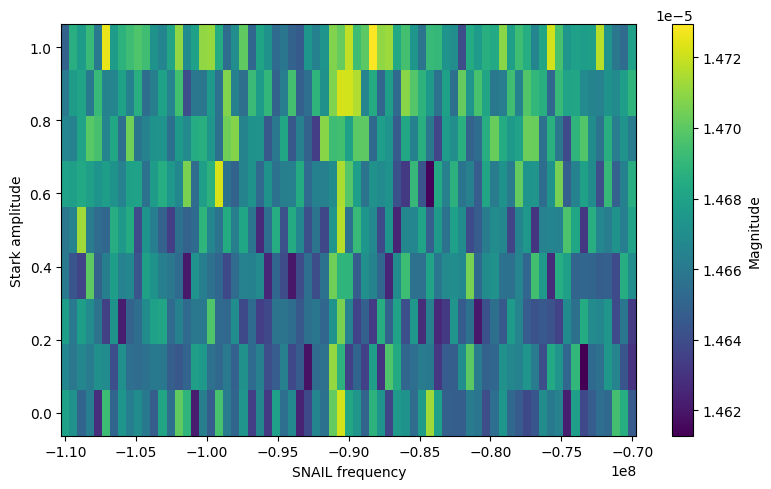

In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt



with h5py.File(filename, "r") as f:
    magnitude = f["Magnitude"][:]       # (136793, 9, 71)
    stark_amp = f["stark_ampx"][:]      # (9,)
    snail_freq = f["snail_frequency"][:]  # (71,)

# Average over the first dimension
mag_avg = np.mean(magnitude, axis=0)    # (9, 71)

print("Magnitude:", magnitude.shape)
print("Averaged:", mag_avg.shape)
print("Stark amplitude:", stark_amp)
print("SNAIL frequency:", snail_freq)

plt.figure(figsize=(8, 5))

plt.pcolormesh(
    snail_freq,
    stark_amp,
    mag_avg,
    shading="auto",
)

plt.xlabel("SNAIL frequency")
plt.ylabel("Stark amplitude")
plt.colorbar(label="Magnitude")
plt.tight_layout()
plt.show()